## **<span style='color:#EA7500	'>Preprocessing</span>**

## **請確保資料與檔案如下述的方式存放**
## **crops_image資料夾裡面有一個crops_image，內層的crops_image則存放11種crops名稱的資料夾，11種crops名稱的資料夾內存放照片，train.ipynb與最外層的crops_image在同一層**

## ***Split Crops Data***

In [ ]:
import splitfolders
# split data
input_folder = 'crops_image\crops_image'

splitfolders.ratio(input_folder, output='crops_image\crops_image_split',
                   seed=42, ratio=(.7, .2, .1),
                   group_prefix=None)

Copying files: 3300 files [00:01, 1746.62 files/s]


## ***Augmentation***

In [ ]:
# import package
import tensorflow as tf
import keras 

tf.__version__
# keras.__version__

'2.15.0'

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
from skimage import io
import os
import numpy as np
# imagedatagenerator產生augment data
datagen = ImageDataGenerator(horizontal_flip=True,fill_mode='constant')
# 依照training/validation/testing data或是不同的分類將資料夾中的圖片進行augmentation
data_dir = 'crops_image\crops_image_split'
for x in ['train', 'val','test']:
    for y in ['atemoya', 'banana', 'bareland', 'cabbage', 'carrot', 'grapes', 'guava', 'mango', 'papaya', 'pineapple', 'pumpkin']:
        s = os.path.join(os.path.join(data_dir, x),y)
        names = os.listdir(s)
        for n in names:
            pic = io.imread(os.path.join(s, n))
            pic = pic.reshape((1, ) + pic.shape)
            i = 0
            for batch in datagen.flow(pic, batch_size=2,
                                      save_to_dir=s,save_prefix='aug',
                                      save_format='png'):
                i += 1
                if i > 2:
                    break


        
    


## **<span style='color:#EA7500	'>Convolutional Neural Network Using Reference</span>**

In [1]:
import os
import torch
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
#確定torch環境
torch.cuda.device_count()
os.environ['CUDA_VISIBLE_DEVICES'] = '%d' % 0
torch.cuda.set_device(0)
torch.cuda.is_available()
torch.cuda.current_device()

0

In [2]:
# reference 資料
# License: BSD
# Author: Sasank Chilamkurthy
# import package
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import pandas as pd
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
from tqdm.auto import tqdm
import random
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [3]:
myseed = 6666  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

- ### **Load Data**

In [4]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
# 將圖片路徑匯入dataloader
data_dir = 'crops_image\crops_image_split'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val','test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val','test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val','test']}
class_names = image_datasets['train'].classes

# 設定使用gpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
class_names[0]

'atemoya'

- ### **Visualize a few images**

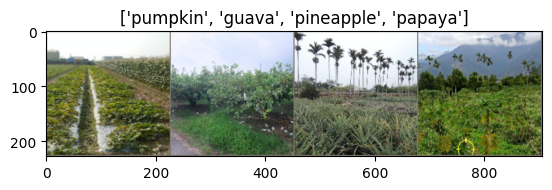

In [6]:
# 可以確認圖片有哪些以及查看label
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [7]:
# 儲存training及validation的loss及accuracy
val_acc = []
train_acc = []
val_loss = []
train_loss = []

- ### **Training the model**

In [8]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=30):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device) # "cpu"
                    labels = labels.to(device) # "cpu"

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()
                # 計算loss及accuracy
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]
                #儲存每個epoch train及validation的loss及accuracy
                if phase == 'train':
                    train_acc.append(epoch_acc)
                    train_loss.append(epoch_loss)
                else:
                    val_acc.append(epoch_acc)
                    val_loss.append(epoch_loss)

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path))
    return model

- ### **Visualizing the model predictions**

In [9]:
# 可以確認圖片有哪些
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

- ### **Finetuning the ConvNet**

In [10]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device) # "cpu"
# 使用crossentropyloss當loss function
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

- ### **Train and evaluate**

In [11]:
# 進行training
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=30)

Epoch 0/29
----------
train Loss: 0.9866 Acc: 0.6741
val Loss: 0.4562 Acc: 0.8668

Epoch 1/29
----------
train Loss: 0.6734 Acc: 0.7792
val Loss: 0.3078 Acc: 0.9033

Epoch 2/29
----------
train Loss: 0.5368 Acc: 0.8291
val Loss: 0.3409 Acc: 0.8927

Epoch 3/29
----------
train Loss: 0.4726 Acc: 0.8500
val Loss: 0.3252 Acc: 0.9163

Epoch 4/29
----------
train Loss: 0.4361 Acc: 0.8620
val Loss: 0.2225 Acc: 0.9292

Epoch 5/29
----------
train Loss: 0.3907 Acc: 0.8773
val Loss: 0.2738 Acc: 0.9174

Epoch 6/29
----------
train Loss: 0.3385 Acc: 0.8921
val Loss: 0.2880 Acc: 0.9117

Epoch 7/29
----------
train Loss: 0.2498 Acc: 0.9214
val Loss: 0.1950 Acc: 0.9384

Epoch 8/29
----------
train Loss: 0.1946 Acc: 0.9382
val Loss: 0.2109 Acc: 0.9334

Epoch 9/29
----------
train Loss: 0.1850 Acc: 0.9424
val Loss: 0.1910 Acc: 0.9422

Epoch 10/29
----------
train Loss: 0.1745 Acc: 0.9456
val Loss: 0.2040 Acc: 0.9361

Epoch 11/29
----------
train Loss: 0.1907 Acc: 0.9407
val Loss: 0.2007 Acc: 0.9357

Ep

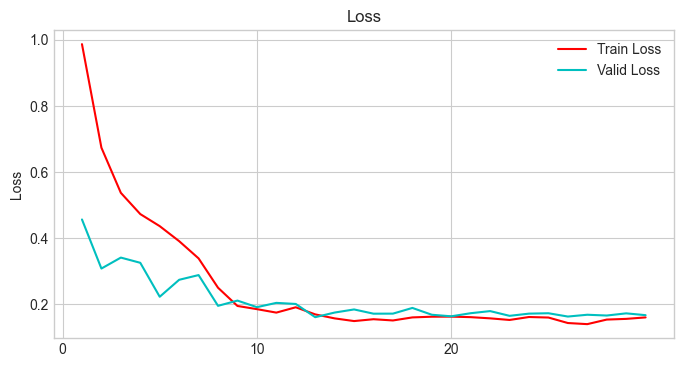

In [12]:
import matplotlib.pyplot as plt
#將loss的數值視覺化
plt.style.use("seaborn-v0_8-whitegrid")
num_epochs = 30
plt.figure(figsize=(8,4))
plt.title("Loss")
plt.ylabel("Loss")
plt.plot(range(1, len(train_loss)+1), train_loss, label="Train Loss", color='r')
plt.plot(range(1, len(val_loss)+1), val_loss, label="Valid Loss", color='c')
plt.xticks(np.arange(0, num_epochs, 10.0), )
plt.legend()
plt.savefig('train_loss.png')
plt.show()

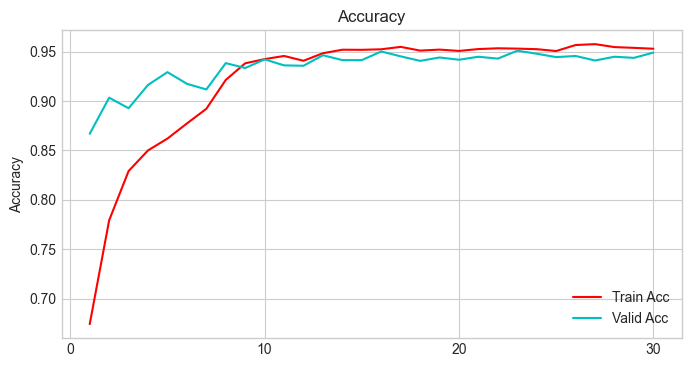

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch
#將accuracy的數值視覺化
train_acc_list = []
train_acc_list = np.array(train_acc_list)
val_acc_list = []
val_acc_list = np.array(val_acc_list)

for i in range(len(train_acc)):
    t = train_acc[i].cpu().numpy()
    v = val_acc[i].cpu().numpy()
    train_acc_list = np.hstack((train_acc_list,t))
    val_acc_list = np.hstack((val_acc_list,v))


plt.style.use("seaborn-v0_8-whitegrid")
num_epochs = 30
plt.figure(figsize=(8,4))
plt.title("Accuracy")
plt.ylabel("Accuracy")
plt.plot(range(1, len(train_acc_list)+1), train_acc_list, label="Train Acc", color='r')
plt.plot(range(1, len(val_acc_list)+1), val_acc_list, label="Valid Acc", color='c')
plt.xticks(np.arange(0, num_epochs+1, 10.0), )
plt.legend()
plt.savefig('train_acc.png')
plt.show()

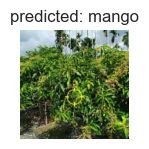

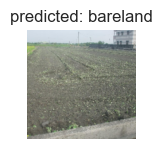

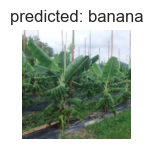

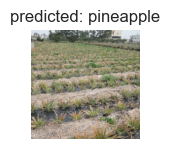

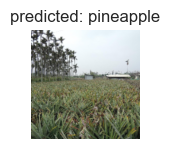

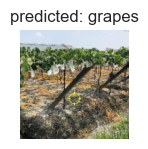

In [14]:
# 可以看圖片預測情形
visualize_model(model_ft)

## ***Testing***

In [15]:
# 進行testing
test_loss = 0.0
class_correct = list(0. for i in range(len(class_names)))
class_total = list(0. for i in range(len(class_names)))
batch_size=4

model_ft.eval()
# 每次load一整個batch進行比對
for data, target in dataloaders['test']:
    data, target = data.to(device), target.to(device)
    # 預測label
    output = model_ft(data)
    # 計算loss
    loss = criterion(output, target)
    test_loss += loss.item()*data.size(0)
    # 獲得機率最大的label
    _, pred = torch.max(output, 1)
    # 比對預測是否正確
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.cpu().numpy())
    # 統計正確次數
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

test_loss = test_loss/dataset_sizes['test']
print(f'Test Loss: {test_loss:.3f}\n')

for i in range(len(class_names)):
    if class_total[i] > 0:
        print(f'Test Accuracy of {class_names[i]}: {100 * class_correct[i] / class_total[i]:.2f}% ({int(np.sum(class_correct[i]))}/{int(np.sum(class_total[i]))})')
    else:
        print(f'Test Accuracy of {class_names[i]}: N/A (no training examples)')

print(f'\nTest Accuracy (Overall): {100. * np.sum(class_correct) / np.sum(class_total):.2f}% ({int(np.sum(class_correct))}/{int(np.sum(class_total))})')

Test Loss: 0.155

Test Accuracy of atemoya: 83.33% (100/120)
Test Accuracy of banana: 100.00% (120/120)
Test Accuracy of bareland: 95.00% (114/120)
Test Accuracy of cabbage: 92.44% (110/119)
Test Accuracy of carrot: 100.00% (120/120)
Test Accuracy of grapes: 92.50% (111/120)
Test Accuracy of guava: 100.00% (120/120)
Test Accuracy of mango: 92.50% (111/120)
Test Accuracy of papaya: 92.50% (111/120)
Test Accuracy of pineapple: 100.00% (120/120)
Test Accuracy of pumpkin: 99.16% (118/119)

Test Accuracy (Overall): 95.22% (1255/1318)


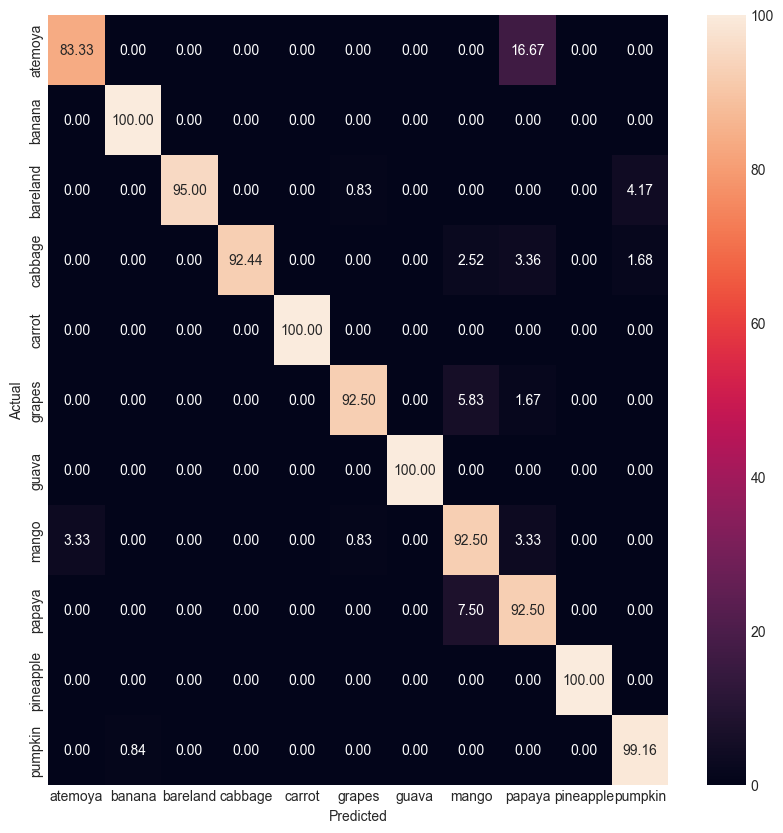

In [16]:
# 將結果畫成confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# After training loop
def visualize_confusion_matrix(model, dataloader):
    was_training = model.training
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    model.train(mode=was_training)

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Normalise
    cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] *100
    fig, ax = plt.subplots(figsize=(10,10))
    sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

# Visualize the confusion matrix
visualize_confusion_matrix(model_ft, dataloaders['test'])

In [17]:
# 儲存model
torch.save(model_ft, 'mymodel.pth')

## **<span style='color:#EA7500	'>Testing After Loading</span>**

## **請確保資料與檔案如下述的方式存放**
## **crops_image資料夾裡面有一個crops_image，內層的crops_image則存放11種crops名稱的資料夾，11種crops名稱的資料夾內存放照片，train.ipynb與最外層的crops_image在同一層**
## **mymodel需與train.ipynb同一層**

## ***Split Crops Data***

In [ ]:
# split data
import splitfolders

input_folder = 'crops_image\crops_image'

splitfolders.ratio(input_folder, output='crops_image\crops_image_split',
                   seed=42, ratio=(.7, .2, .1),
                   group_prefix=None)

Copying files: 3300 files [00:01, 1746.62 files/s]


## ***Augmentation***

In [ ]:
# import package
import tensorflow as tf
import keras 

tf.__version__
# keras.__version__

'2.15.0'

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
from skimage import io
import os
import numpy as np
# imagedatagenerator產生augment data
datagen = ImageDataGenerator(horizontal_flip=True,fill_mode='constant')
# 依照training/validation/testing data或是不同的分類將資料夾中的圖片進行augmentation
data_dir = 'crops_image\crops_image_split'
for x in ['train', 'val','test']:
    for y in ['atemoya', 'banana', 'bareland', 'cabbage', 'carrot', 'grapes', 'guava', 'mango', 'papaya', 'pineapple', 'pumpkin']:
        s = os.path.join(os.path.join(data_dir, x),y)
        names = os.listdir(s)
        for n in names:
            pic = io.imread(os.path.join(s, n))
            pic = pic.reshape((1, ) + pic.shape)
            i = 0
            for batch in datagen.flow(pic, batch_size=2,
                                      save_to_dir=s,save_prefix='aug',
                                      save_format='png'):
                i += 1
                if i > 2:
                    break


        
    


In [18]:
import os
import torch
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
#確定torch環境
torch.cuda.device_count()
os.environ['CUDA_VISIBLE_DEVICES'] = '%d' % 0
torch.cuda.set_device(0)
torch.cuda.is_available()
torch.cuda.current_device()

0

In [19]:
# reference 資料
# License: BSD
# Author: Sasank Chilamkurthy
# import packages
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import pandas as pd
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
from tqdm.auto import tqdm
import random
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [20]:
myseed = 6666  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

- ### **Load Data**

In [21]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
# 將圖片路徑匯入dataloader
data_dir = 'crops_image\crops_image_split'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val','test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val','test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val','test']}
class_names = image_datasets['train'].classes

# 設定使用gpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

- ### **Visualize a few images**

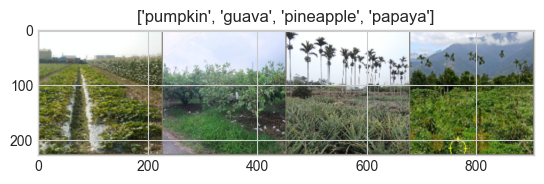

In [22]:
# 可以確認圖片有哪些以及查看label
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [23]:
# 將train好的model匯入
model_ft = torch.load('mymodel.pth')

In [24]:
# 進行testing
test_loss = 0.0
class_correct = list(0. for i in range(len(class_names)))
class_total = list(0. for i in range(len(class_names)))
batch_size=4
criterion = nn.CrossEntropyLoss()
model_ft.eval()
# 每次load一整個batch進行比對
for data, target in dataloaders['test']:
    data, target = data.to(device), target.to(device)
    # 預測label
    output = model_ft(data)
    # 計算loss
    loss = criterion(output, target)
    test_loss += loss.item()*data.size(0)
    # 獲得機率最大的label
    _, pred = torch.max(output, 1)
    # 比對預測是否正確
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.cpu().numpy())
    # 統計正確次數
    for i in range(len(target)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

test_loss = test_loss/dataset_sizes['test']
print(f'Test Loss: {test_loss:.3f}\n')

for i in range(len(class_names)):
    if class_total[i] > 0:
        print(f'Test Accuracy of {class_names[i]}: {100 * class_correct[i] / class_total[i]:.2f}% ({int(np.sum(class_correct[i]))}/{int(np.sum(class_total[i]))})')
    else:
        print(f'Test Accuracy of {class_names[i]}: N/A (no training examples)')

print(f'\nTest Accuracy (Overall): {100. * np.sum(class_correct) / np.sum(class_total):.2f}% ({int(np.sum(class_correct))}/{int(np.sum(class_total))})')

Test Loss: 0.155

Test Accuracy of atemoya: 83.33% (100/120)
Test Accuracy of banana: 100.00% (120/120)
Test Accuracy of bareland: 95.00% (114/120)
Test Accuracy of cabbage: 92.44% (110/119)
Test Accuracy of carrot: 100.00% (120/120)
Test Accuracy of grapes: 92.50% (111/120)
Test Accuracy of guava: 100.00% (120/120)
Test Accuracy of mango: 92.50% (111/120)
Test Accuracy of papaya: 92.50% (111/120)
Test Accuracy of pineapple: 100.00% (120/120)
Test Accuracy of pumpkin: 99.16% (118/119)

Test Accuracy (Overall): 95.22% (1255/1318)


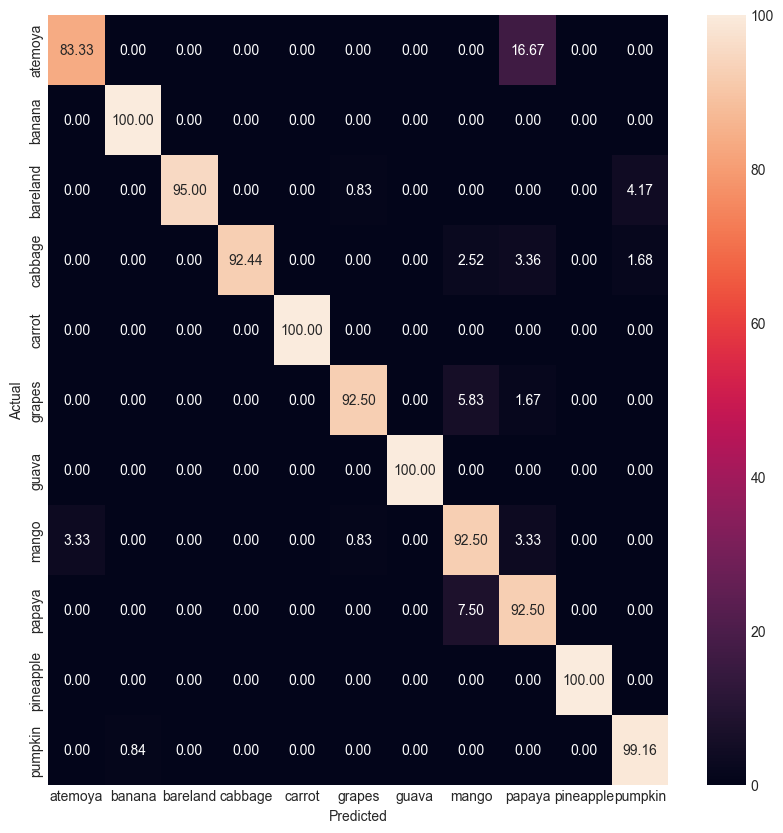

In [25]:
# 將結果畫成confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# After training loop
def visualize_confusion_matrix(model, dataloader):
    was_training = model.training
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    model.train(mode=was_training)

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Normalise
    cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] *100
    fig, ax = plt.subplots(figsize=(10,10))
    sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('fig01.jpg')
    
    

# Visualize the confusion matrix
visualize_confusion_matrix(model_ft, dataloaders['test'])